# Gaming Industry EDA (Ye Ou)

This notebook explores a dataset of 1000 gaming industry records, including game genre, platform, player base, and revenue performance.

The goal is to understand what factors influence revenue (millions of dollars), which is used as the dependent variable.


In [ ]:
#Here is my dataset:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/gaming_industry_trends.csv")

df.head()

,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
0,Neon Speed 5,Strategy,Xbox,2011,Capcom,52.28,77.99,21.44,69,No,Stable
1,Cyber Quest 5,Shooter,Mobile,2018,Bandai Namco,4345.97,65.28,11.22,72,No,Stable
2,Fantasy Rivals 1,Strategy,Xbox,2018,Microsoft,1278.29,160.09,48.40,51,Yes,Declining
3,Warzone Chronicles 5,Horror,Xbox,2002,Microsoft,361.26,98.14,32.96,91,No,Declining
4,Cyber Quest 4,RPG,PC,2018,EA,4549.27,199.47,58.39,74,No,Stable


In [ ]:
# DATA OVERVIEW
# We first inspect dataset structure, variable types, and overall size.

df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               1000 non-null   str    
 1   Genre                    1000 non-null   str    
 2   Platform                 1000 non-null   str    
 3   Release Year             1000 non-null   int64  
 4   Developer                1000 non-null   str    
 5   Revenue (Millions $)     1000 non-null   float64
 6   Players (Millions)       1000 non-null   float64
 7   Peak Concurrent Players  1000 non-null   float64
 8   Metacritic Score         1000 non-null   int64  
 9   Esports Popularity       1000 non-null   str    
 10  Trending Status          1000 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 86.1 KB


In [3]:
# DATA CHECK

df.isnull().sum()

Game Title                 0
Genre                      0
Platform                   0
Release Year               0
Developer                  0
Revenue (Millions $)       0
Players (Millions)         0
Peak Concurrent Players    0
Metacritic Score           0
Esports Popularity         0
Trending Status            0
dtype: int64

In [ ]:
# Duplicates

df.duplicated().sum()

np.int64(0)

### The dataset contains no missing values or duplicate rows, so no cleaning is required.

In [6]:
# SUMMARY STATISTICS

df.describe()

,Release Year,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2012.074000,2483.017800,103.499820,31.602150,74.990000
std,7.031356,1412.629451,58.869562,23.023375,14.618536
min,2000.000000,11.430000,0.530000,0.110000,50.000000
25%,2006.000000,1276.190000,52.005000,12.967500,62.000000
50%,2012.000000,2476.130000,107.040000,26.405000,76.000000
75%,2018.000000,3677.797500,155.632500,46.020000,87.000000
max,2024.000000,4999.790000,199.980000,96.620000,100.000000


### This provides distribution insights for all numeric variables, including revenue, players, and ratings.

In [7]:
#DEPENDENT VARIABLE

df["Revenue (Millions $)"].describe()

count    1000.000000
mean     2483.017800
std      1412.629451
min        11.430000
25%      1276.190000
50%      2476.130000
75%      3677.797500
max      4999.790000
Name: Revenue (Millions $), dtype: float64

### Revenue distribution shows variation across games, with most games concentrated in mid-range values.

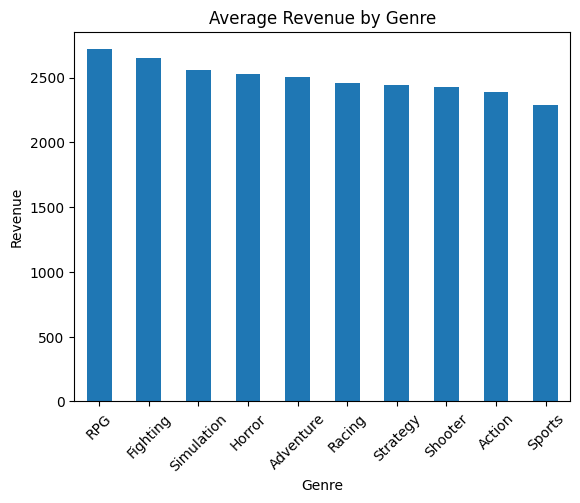

In [8]:
# GENRE vs REVENUE

genre_rev = df.groupby("Genre")["Revenue (Millions $)"].mean().sort_values(ascending=False)

genre_rev.plot(kind="bar")
plt.title("Average Revenue by Genre")
plt.xlabel("Genre")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Some genres generate higher average revenue, indicating genre influences commercial performance.

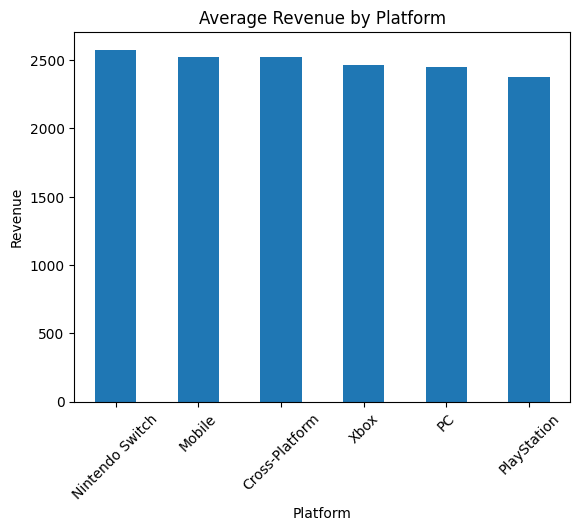

In [9]:
# PLATFORM vs REVENUE

platform_rev = df.groupby("Platform")["Revenue (Millions $)"].mean().sort_values(ascending=False)

platform_rev.plot(kind="bar")
plt.title("Average Revenue by Platform")
plt.xlabel("Platform")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Platform choice also impacts revenue distribution, suggesting distribution channels matter in performance.

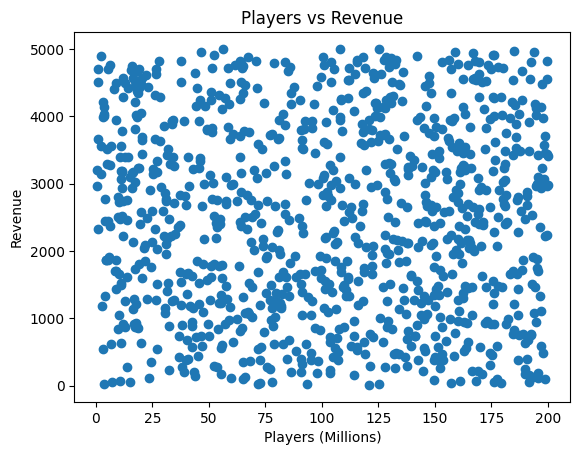

In [10]:
# PLAYER BASE vs REVENUE

plt.scatter(df["Players (Millions)"], df["Revenue (Millions $)"])
plt.title("Players vs Revenue")
plt.xlabel("Players (Millions)")
plt.ylabel("Revenue")
plt.show()

### We analyze whether player base size has a relationship with revenue generation.

In [11]:
# CORRELATION ANALYSIS

df.corr(numeric_only=True)

,Release Year,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score
Release Year,1.000000,0.009146,0.011047,0.006162,0.018043
Revenue (Millions $),0.009146,1.000000,-0.016526,-0.029578,0.015595
Players (Millions),0.011047,-0.016526,1.000000,0.799776,-0.006388
Peak Concurrent Players,0.006162,-0.029578,0.799776,1.000000,0.024037
Metacritic Score,0.018043,0.015595,-0.006388,0.024037,1.000000


### Correlation results show weak relationships overall, suggesting revenue is influenced by multiple factors rather than a single predictor.

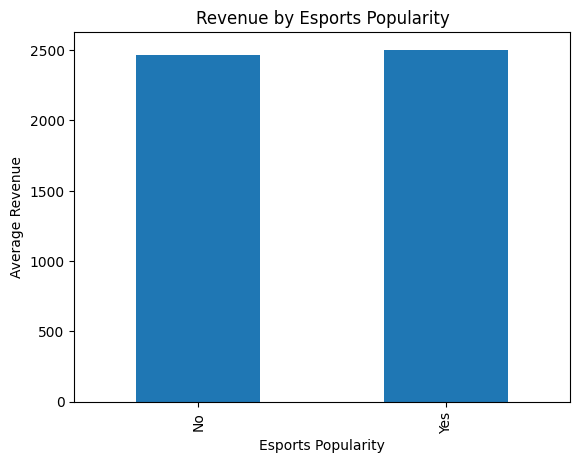

In [12]:
# ESports POPULARITY IMPACT

df.groupby("Esports Popularity")["Revenue (Millions $)"].mean().plot(kind="bar")
plt.title("Revenue by Esports Popularity")
plt.xlabel("Esports Popularity")
plt.ylabel("Average Revenue")
plt.show()

# FINAL SUMMARY

## Key Findings

- Revenue is highly variable across games
- Genre and platform both influence average revenue
- Player base shows a visible relationship with revenue
- Esports popularity may impact revenue performance
- Correlation between variables is generally weak

## Conclusion

Revenue is influenced by multiple factors rather than a single variable, making it a multi-dimensional prediction problem.